
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Jesus! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

Sigue así!

</div>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

- La columna `date` es de tipo `object` y debe ser convertida a `datetime64`
- No hay valores nulos en el df ("landing_experiment.csv")

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

<div class="alert alert-block alert-success">
<b>Exploracion Inicial</b> <a class="tocSkip"></a>

Excelente! Utilizaste correctamente head() e info() para obtener una primera vista del dataset. 


</div>

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


In [8]:
# Conviertiendo el formato de `date` a `datetime64`
df['date'] = pd.to_datetime(df['date'], errors='coerce')

**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df['gasto'].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [10]:
# Resumen estadístico de usuarios que se convirtieron
user_convertio = df[df['converted'] == 1] 
user_convertio['gasto'].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
var = ['region', 'dispositivo', 'traffic_source', 'user_type']

cat_var = [col for col in var if col in df.columns]

for col in cat_var:
    unique_val = df[col].unique()
    separador = '\n'
    print(f"\nLos valores unicos de la columna {col} son:\n{separador.join(unique_val)}")
    print(f"\nLa distribucion de la columna {col} es: \n{df[col].value_counts(normalize=True) * 100}\n")


Los valores unicos de la columna region son:
Norte
Occidente
Centro
Sur
Oriente

La distribucion de la columna region es: 
Norte        27.9150
Centro       24.0325
Sur          20.0975
Occidente    15.9950
Oriente      11.9600
Name: region, dtype: float64


Los valores unicos de la columna dispositivo son:
Mobile
Desktop

La distribucion de la columna dispositivo es: 
Mobile     62.0725
Desktop    37.9275
Name: dispositivo, dtype: float64


Los valores unicos de la columna traffic_source son:
Email
Organic
Ads
Referral

La distribucion de la columna traffic_source es: 
Organic     44.9675
Ads         29.8375
Email       15.3075
Referral     9.8875
Name: traffic_source, dtype: float64


Los valores unicos de la columna user_type son:
Recurrente
Nuevo

La distribucion de la columna user_type es: 
Nuevo         65.0825
Recurrente    34.9175
Name: user_type, dtype: float64



In [12]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
for col in cat_var:
    print("\n", df[col].describe())


Conteo de categorías:

 count     40000
unique        5
top       Norte
freq      11166
Name: region, dtype: object

 count      40000
unique         2
top       Mobile
freq       24829
Name: dispositivo, dtype: object

 count       40000
unique          4
top       Organic
freq        17987
Name: traffic_source, dtype: object

 count     40000
unique        2
top       Nuevo
freq      26033
Name: user_type, dtype: object


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves

- En las columnas categoricas, no hay valores atipicos.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [13]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

<div class="alert alert-block alert-success">
<b>Filtro de Clientes y Gasto Promedio</b> <a class="tocSkip"></a>

Filtraste correctamente solo los usuarios convertidos (converted = 1).

</div>

In [14]:
# gasto_A.head()

In [15]:
gasto_A.describe()

count    2512.000000
mean       61.086572
std        28.875470
min        12.120000
25%        40.612500
50%        55.840000
75%        74.837500
max       303.680000
Name: gasto, dtype: float64

In [16]:
gasto_B.describe()

count    3194.00000
mean       68.74536
std        32.00102
min        12.98000
25%        45.21000
50%        62.57000
75%        84.27750
max       249.99000
Name: gasto, dtype: float64

### Prueba t de Student (t-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** El gasto promedio es igual para el Grupo A y el Grupo B
- **Hipótesis alternativa (H₁):** El gasto promedio **NO** es igual para el Grupo A y B

<div class="alert alert-block alert-success">
<b>Definicion de Hipotesis</b> <a class="tocSkip"></a>

Las hipotesis nula (H0) y alternativa (H1) estan correctamente formuladas y son coherentes con el objetivo del analisis. Una hipotesis bien planteada es la base de cualquier prueba estadistica rigurosa.

</div>

In [17]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadistico t: {t_stat}")
print(f"Valor P: {p_value}")

alpha = 0.05

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Estadistico t: -9.36563589591332
Valor P: 1.0635288333792346e-20
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


<div class="alert alert-block alert-danger">
<b>Prueba de Levene</b> <a class="tocSkip"></a>

No se aplico la prueba de Levene. Antes de ejecutar el t-test, es necesario verificar si las varianzas de ambos grupos son homogeneas. Si son iguales, se usa equal_var=True; si son distintas (p-value de Levene menor a 0.05), se debe usar equal_var=False, que corresponde a la prueba de Welch.

<div class="alert alert-block alert-success">
<b>Test Estadistico — t-test</b> <a class="tocSkip"></a>

Aplicaste correctamente el t-test y reportaste tanto el estadistico t_stat como el p-value.

</div>

</div>

In [18]:
mobile_gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1) & (df['dispositivo'] == 'Mobile')]['gasto']
desktop_gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1) & (df['dispositivo'] == 'Desktop')]['gasto']

mobile_gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1) & (df['dispositivo'] == 'Mobile')]['gasto']
desktop_gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1) & (df['dispositivo'] == 'Desktop')]['gasto']

print(f"Resumen estadistico del gasto del grupo A que usan Mobile: \n{mobile_gasto_A.describe()}")
print(f"\nResumen estadistico del gasto del grupo A que usan Desktop: \n{desktop_gasto_A.describe()}")
print(f"\nResumen estadistico del gasto del grupo B que usan Mobile: \n{mobile_gasto_B.describe()}")
print(f"\nResumen estadistico del gasto del grupo B que usan Desktop: \n{desktop_gasto_B.describe()}")

Resumen estadistico del gasto del grupo A que usan Mobile: 
count    1398.000000
mean       59.560515
std        27.370779
min        12.120000
25%        39.910000
50%        54.400000
75%        73.220000
max       206.040000
Name: gasto, dtype: float64

Resumen estadistico del gasto del grupo A que usan Desktop: 
count    1114.000000
mean       63.001679
std        30.564268
min        14.820000
25%        41.377500
50%        57.310000
75%        76.647500
max       303.680000
Name: gasto, dtype: float64

Resumen estadistico del gasto del grupo B que usan Mobile: 
count    1865.000000
mean       67.781609
std        31.544809
min        12.980000
25%        43.940000
50%        62.210000
75%        84.210000
max       249.990000
Name: gasto, dtype: float64

Resumen estadistico del gasto del grupo B que usan Desktop: 
count    1329.000000
mean       70.097803
std        32.594367
min        13.120000
25%        46.790000
50%        63.140000
75%        84.460000
max       244.890000

In [19]:
# desktop_gasto_A.describe()

### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
- Se rechaza la hipotesis nula.

**Interpretación de negocio:**  
Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B.
- El grupo que genera mayor gasto en promedio es el grupo B y el valor-p ($ p < 0.05$) confirma que esa diferencia no depende del azar (compras gigantes de unos cuantos usuarios - outliers)




<div class="alert alert-block alert-success">
<b>Interpretacion — Gasto Promedio</b> <a class="tocSkip"></a>

Muy bien! La interpretacion del resultado es clara y esta redactada en terminos de negocio. 

Efectivamente debemos rechazar la hipótesis nula.

Explicaste correctamente el significado del p-value y lo vinculaste a una conclusion accionable sobre las landings.
</div>

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba z de Proporciones (z-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversion entre el Grupo A y el Grupo B es la misma.
- **Hipótesis alternativa (H₁):** La tasa de conversion **NO** es igual entre el Grupo A y el Grupo B.

In [20]:
# Número de usuarios convertidos por página
# mobile_gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1) & (df['dispositivo'] == 'Mobile')]['gasto']

grupo_A = df[df['landing'] == 'A']
grupo_B = df[df['landing'] == 'B']

total_grupo_A = grupo_A.groupby('converted')['user_id']\
    .agg(['count'])\
    .reset_index()\
    .sort_values(by='count', ascending=False)

total_grupo_B  = grupo_B.groupby('converted')['user_id']\
    .agg(['count'])\
    .reset_index()\
    .sort_values(by='count', ascending=False)

convert_grupo_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]
convert_grupo_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]

print(f"El total de usuarios del grupo A es: \n{total_grupo_A}")
print(f"\nEl total de usuarios del grupo B es: \n{total_grupo_B}")
print(f"\nDistribucion de usuarios que [SI (1) | NO (0)] convirtieron en el Grupo A es:\n{grupo_A['converted'].value_counts(normalize=True) * 100}")
print(f"\nDistribucion de usuarios que [SI (1) | NO (0)] convirtieron en el Grupo B es:\n{grupo_B['converted'].value_counts(normalize=True) * 100}")

El total de usuarios del grupo A es: 
   converted  count
0          0  17470
1          1   2512

El total de usuarios del grupo B es: 
   converted  count
0          0  16824
1          1   3194

Distribucion de usuarios que [SI (1) | NO (0)] convirtieron en el Grupo A es:
0    87.428686
1    12.571314
Name: converted, dtype: float64

Distribucion de usuarios que [SI (1) | NO (0)] convirtieron en el Grupo B es:
0    84.04436
1    15.95564
Name: converted, dtype: float64


In [21]:
# Filtrar y contar la cantidad de exitos (conversiones) en cada pagina.

conversiones = df.groupby('landing')['converted'].sum()
total = df.groupby('landing')['converted'].count()
exitos = [conversiones['A'], conversiones['B']]
observaciones = [total['A'], total['B']]

print(f"La conversiones entre el grupo A y B es: {conversiones}")
print(f"\nEl total de usuarios entre el grupo A y B es: {total}")
print()

# Aplicar prueba
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(exitos, observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05 

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

La conversiones entre el grupo A y B es: landing
A    2512
B    3194
Name: converted, dtype: int64

El total de usuarios entre el grupo A y B es: landing
A    19982
B    20018
Name: converted, dtype: int64

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22
Rechazamos la hipótesis nula: hay evidencia de una diferencia.


<div class="alert alert-block alert-success">
<b>Test Estadistico — z-test de Proporciones</b> <a class="tocSkip"></a>

Aplicaste correctamente el test para comparar las tasas de conversion entre las dos landings. Este es el test adecuado para comparar proporciones en muestras grandes y lo implementaste de forma precisa.

Efectivamente, rechazamos la hipótesis nula ya que hay evidencia de una dirferencia. 

</div>

In [22]:
tasa_grupo_A = exitos[0] / observaciones[0]
tasa_grupo_B = exitos[1] / observaciones[1]

print(f"Tasa de conversión página A: {tasa_grupo_A:.2%}")
print(f"Tasa de conversión página B: {tasa_grupo_B:.2%}")

# Interpretar dirección de resultados
if tasa_grupo_A > tasa_grupo_B:
    print(f"\nLa página A tiene una mayor tasa de conversión ({tasa_grupo_A - tasa_grupo_B:.2%}).")
elif tasa_grupo_B > tasa_grupo_A:
    print(f"\nLa página B tiene una mayor tasa de conversión ({tasa_grupo_B - tasa_grupo_A:.2%})")
else:
    print("\nAmbas páginas tienen la misma tasa de conversión.")

# print(20018 * 0.0338)

Tasa de conversión página A: 12.57%
Tasa de conversión página B: 15.96%

La página B tiene una mayor tasa de conversión (3.38%)


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

- Se rechaza la hipotesis nula ya que la diferencia entre la tasa de conversion entre la pagina A/B es estadisticamente significativa ($p-value \approx 3.75e-22$)

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B.

- La pagina B convierte mas usuarios con un 3.38% mas.
- El grupo B tiene 20018 y un 3.38% de conversion significan unos 676 usuarios adicionales.


## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado (chi2)

**Hipótesis:**
- **Hipótesis nula (H₀):** Todas las fuentes de trafico generan la misma conversion.
- **Hipótesis alternativa (H₁):** **NO** todas las fuentes de trafico generan la misma conversion.

In [23]:
# Tabla de contingencia

tabla = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [24]:

# Aplicar prueba
chi2_contingency(tabla)

chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)


Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [25]:

alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre las variables.")


Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.


<div class="alert alert-block alert-success">
<b>Interpretacion — Trafico y Conversion</b> <a class="tocSkip"></a>

El insight extraido sobre la relacion entre la fuente de trafico y la conversion es claro. Podemos decir que hay evidencia de asociación entre las variables. 

</div>

In [26]:
total = df.groupby('traffic_source')['converted'].count()
conversion = df.groupby('traffic_source')['converted'].sum()
proporcion = df.groupby('traffic_source')['converted'].value_counts(normalize=True) * 100

print(total)
print()
print(conversion)
print()
print(proporcion)

traffic_source
Ads         11935
Email        6123
Organic     17987
Referral     3955
Name: converted, dtype: int64

traffic_source
Ads         1759
Email        918
Organic     2480
Referral     549
Name: converted, dtype: int64

traffic_source  converted
Ads             0            85.261835
                1            14.738165
Email           0            85.007349
                1            14.992651
Organic         0            86.212264
                1            13.787736
Referral        0            86.118837
                1            13.881163
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
- Se rechaza la hipotesis nula. el p-value dice que hay evidencia significativa de que la tasa de conversion no es la misma entre las fuentes de trafico.

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.
- La fuente de trafico mas efectiva es Email con una tasa de conversion del ~15%. 
- Las demas fuentes tienen una tasa de conversion: Ads (14.7%), Organic (13.78%) y Referral (13.88%)

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado

**Hipótesis:**
- **Hipótesis nula (H₀):** **No** existe relacion entre el tipo de usuario `user_type` y la tasa de conversion `converted`.
- **Hipótesis alternativa (H₁):** Existe una relacion entre el tipo de usuario `user_type` y la tasa de conversion `converted`.

In [27]:
# Crear tabla de contingencia.
tabla5 = pd.crosstab(df['converted'], df['user_type'])
print(tabla5)

print()
tabla5_norm = pd.crosstab(df['converted'], df['user_type'], normalize='index') * 100
print(tabla5_norm)

proporcion5 = df.groupby('user_type')['converted'].value_counts(normalize=True) * 100
print()
print(proporcion5)

user_type  Nuevo  Recurrente
converted                   
0          22295       11999
1           3738        1968

user_type      Nuevo  Recurrente
converted                       
0          65.011372   34.988628
1          65.509989   34.490011

user_type   converted
Nuevo       0            85.641301
            1            14.358699
Recurrente  0            85.909644
            1            14.090356
Name: converted, dtype: float64


In [28]:
# Aplicar prueba
chi2_contingency(tabla5)

chi2_stat, p_value, dof, expected = chi2_contingency(tabla5)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255 11974.60745]
 [ 3713.60745  1992.39255]]


In [29]:

alpha = 0.05  # umbral de significancia

if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre las variables.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente de asociación entre las variables.")


No rechazamos la hipótesis nula: No hay evidencia suficiente de asociación entre las variables.


<div class="alert alert-block alert-success">
<b>Interpretacion — Nuevos vs. Recurrentes</b> <a class="tocSkip"></a>

Excelente! Comparaste efectivamente el comportamiento de conversion entre usuarios nuevos y recurrentes, y tradujiste los hallazgos en una conclusion con valor estrategico. 

No rechazamos la hipótesis en este caso, ya que no hay evidencia suficiente de asociación entre las variables. 

</div>

### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)
- Teniendo en cuenta que las tasas de conversion estan muy cercanas entre si (14.46% para nuevos y 14.09% para recurrentes) y el p-value confirma que la diferencia no es estadisticamente significativa. 
- **NO** se rechaza la hipotesis nula. No hay evidencia de asociacion ($p \approx 0.47$) entre el tipo de usuario `user_type` y la tasa de conversion `converted`. 

**Interpretación de negocio:**  

- El tipo de usuario `user_type` no es un factor determinante en la tasa de conversión. A diferencia de `traffic_source`, donde sí se encontró una asociación significativa.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

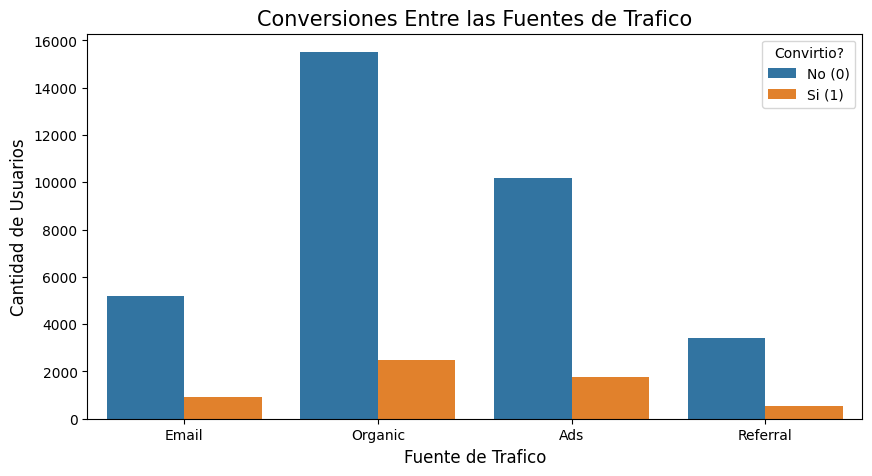

In [30]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted')

plt.title('Conversiones Entre las Fuentes de Trafico', fontsize=15)
plt.xlabel('Fuente de Trafico', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.legend(title='Convirtio?', labels=['No (0)', 'Si (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

- Aunque `Organic` lidera en volumen absoluto de conversiones (2480), no es la fuente más efectiva. `Email` presenta la mayor tasa de conversión (~14.99%), lo que sugiere que los usuarios que llegan por `email` tienen mayor intención de compra.

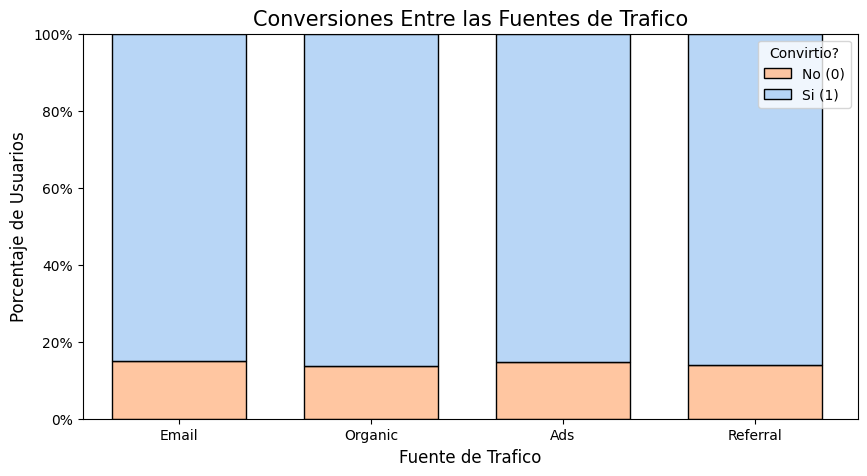

In [31]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 5))

sns.histplot(data=df, 
             x='traffic_source', 
             hue='converted', 
             multiple='fill', 
            shrink=0.7,
            palette='pastel')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Conversiones Entre las Fuentes de Trafico', fontsize=15)
plt.xlabel('Fuente de Trafico', fontsize=12)
plt.ylabel('Porcentaje de Usuarios', fontsize=12)
plt.legend(title='Convirtio?', labels=['No (0)', 'Si (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

- El gráfico de proporciones confirma que email tiene la mayor tasa de conversión (~15%), superando a organic (13.8%), a pesar de que organic tiene el mayor volumen absoluto de usuarios. Esto refuerza que la efectividad de una fuente de tráfico no depende de su volumen, sino de la calidad de los usuarios que atrae.

### Relación entre el tipo de usuario y la conversión

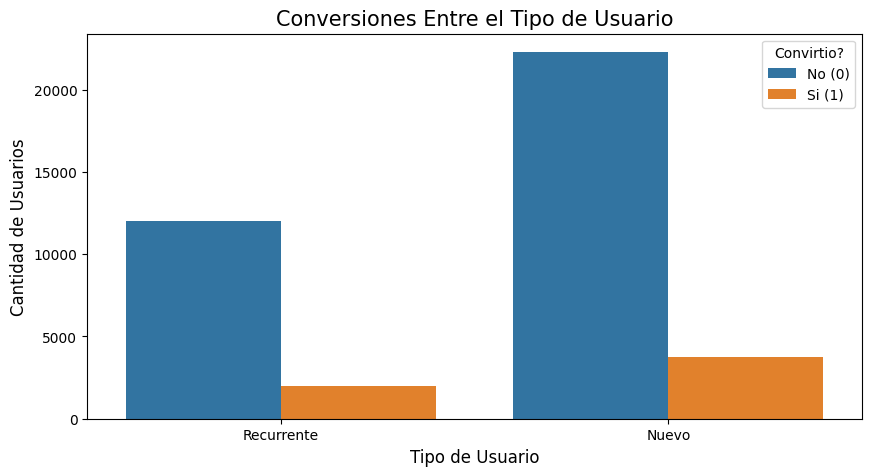

In [32]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted')

plt.title('Conversiones Entre el Tipo de Usuario', fontsize=15)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.legend(title='Convirtio?', labels=['No (0)', 'Si (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

- Inclusive cuando los usuarios nuevos representan el mayor numero absoluto de usuarios que realizan conversiones, la afectividad de conversion entre usuarios nuevos y recurrentes es muy similar con un 14.09% para usuarios recurrentes y 14.35% para usuarios nuevos.



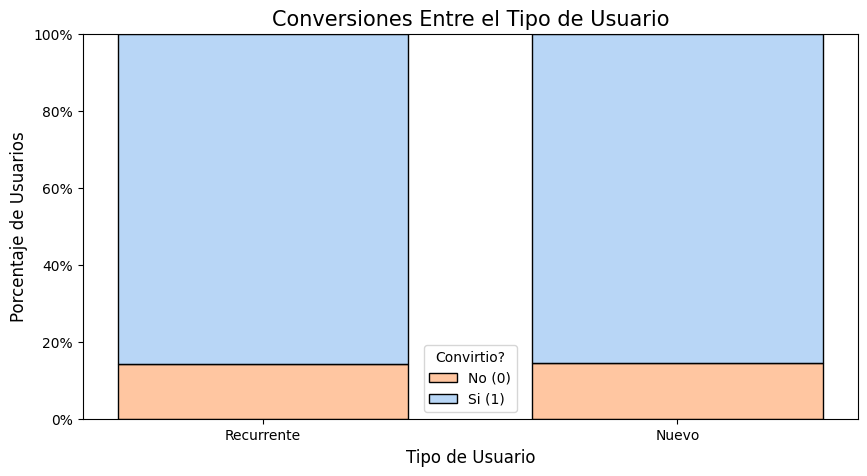

In [33]:
import matplotlib.ticker as mtick

plt.figure(figsize=(10, 5))

sns.histplot(data=df, 
             x='user_type', 
             hue='converted', 
             multiple='fill', 
            shrink=0.7,
            palette='pastel')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Conversiones Entre el Tipo de Usuario', fontsize=15)
plt.xlabel('Tipo de Usuario', fontsize=12)
plt.ylabel('Porcentaje de Usuarios', fontsize=12)
plt.legend(title='Convirtio?', labels=['No (0)', 'Si (1)'])
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y complementa el gráfico con un breve texto que explique qué estamos viendo.

- Este grafico de barras apiladas entre los usuarios nuevos y recurrentes refuerza los resultados de la prueba chi2 ($p \approx 0.47$)  donde no se encontre relacion estadisticamente significativa entre el tipo de usuario y su tasa de conversion.



<div class="alert alert-block alert-success">
<b>Graficos Clave</b> <a class="tocSkip"></a>

Los graficos son claros, informativos y estan bien construidos. 

Además, los comentarios son muy buenos. 

Excelente trabajo!

</div>

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El gasto promedio es mayor en la pagina B, con 68.74 USD, en comparacion con los 61.08 USD de la pagina A. El resultado de la prueba t-test ($p-value \approx 1.063e-20$) confirma los resultados son estadisticamente significativos y no dependen del azar.
- **Interpretación:** En promedio, los usuarios que llegan a la pagina B tienden a gastar mas.

<br>

**Tasa de conversión:** 
- La tasa de conversion de la pagina B es mejor con un 3.38% mas que la pagina A.
- **Interpretación:** Los usuarios que llegan a la pagina B tiene un 3.38% mas de intencion de compra.

---

#### 📊 **Segmentación por fuente de tráfico**
- La fuente de trafico con la mejor tasa de conversion es email con un ~15%, el resultado de la prueba chi2 ($p \approx 0.034$) confirma que los resultados son estadisticamente significativos y no dependen del azar.
- **Interpretación:** Esto indica que los usuarios que llegan por email (ya sea a la pagina a o b) tienen una mayor intencion de compra.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- La tasa de conversion entre los usuarios nuevos y recurrentes es muy similar, menos del 1% de diferencia, y los resultados de la prueba chi2 ($p \approx 0.47$) confirman que no hay relacion estadisticamente significativa. 

- **Interpretación:** Esto indica que hacer campanas de marketing con el objectivo de aumentar la tasa de conversion no seria efectiva.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Se recomienda implementar la pagina B debido a su mejor tasa de conversion (15.96%) y gasto promedio (68.74 USD) en comparacion con el 12.57% de conversion y 61.08 USD de gasto promedio de la pagina A, un por porcentaje absoluto de 3.38% mas. Los resultados de la prueba t-test ($p \approx 1.063e-20$) confirman que los resultados son estadisticamente significativos.
- Por otra parte se recomienda enforcar los esfuerzos de marketing para atraer mas usuarios por el canal de email ya que tienen la mejor tasa de conversion (~15%) lo cual se veria reflejado en un incremento del gasto promedio. Los valores de la prueba chi2 ($p \approx 0.034$) confirman que los resultados son estadisticamente significativos y no dependen del azar.